In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [3]:
pip install dagshub mlflow scikit-learn pandas matplotlib seaborn skops

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 82.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 68.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.9 MB/s eta 0:00:00
  Attempting uninstall: dacite


In [6]:
import dagshub
import mlflow
import mlflow.sklearn
dagshub.init(repo_owner='kgord23', repo_name='ML_hw_01_House-Prices', mlflow=True)

Initialized MLflow to track repo "kgord23/ML_hw_01_House-Prices"

Repository kgord23/ML_hw_01_House-Prices initialized!

<h1>Data_loading</h1>

In [7]:
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')


In [8]:

train.shape

(1460, 81)

In [9]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [10]:

from sklearn.model_selection import train_test_split
X=train.drop(columns='SalePrice')
Y=train['SalePrice']

X_train, X_val, Y_train, Y_val=train_test_split(X, Y, test_size=0.2, random_state=42)

In [11]:
X_train.shape, X_val.shape

((1168, 80), (292, 80))

In [12]:
X_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
254,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1066,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal
638,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal
799,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal
380,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal


In [13]:
X_train.isna()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
254,False,False,False,False,False,False,True,False,False,False,...,False,False,True,True,True,False,False,False,False,False
1066,False,False,False,False,False,False,True,False,False,False,...,False,False,True,True,True,False,False,False,False,False
638,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,True,False,False,False,False,False
799,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,True,False,False,False,False,False
380,False,False,False,False,False,False,False,False,False,False,...,False,False,True,True,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,False,False,False,False,False,False,True,False,False,False,...,False,False,True,True,True,False,False,False,False,False
1130,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,True,False,False,False,False,False
1294,False,False,False,False,False,False,True,False,False,False,...,False,False,True,True,True,False,False,False,False,False
860,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,True,False,False,False,False,False


In [14]:
X_train.isna().sum().sort_values(ascending=False)

PoolQC           1162
MiscFeature      1122
Alley            1094
Fence             935
MasVnrType        683
                 ... 
MiscVal             0
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
Length: 80, dtype: int64

In [15]:
missing_percent = X_train.isna().mean() * 100
missing_percent.sort_values(ascending=False)


PoolQC           99.486301
MiscFeature      96.061644
Alley            93.664384
Fence            80.051370
MasVnrType       58.476027
                   ...    
MiscVal           0.000000
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
Length: 80, dtype: float64

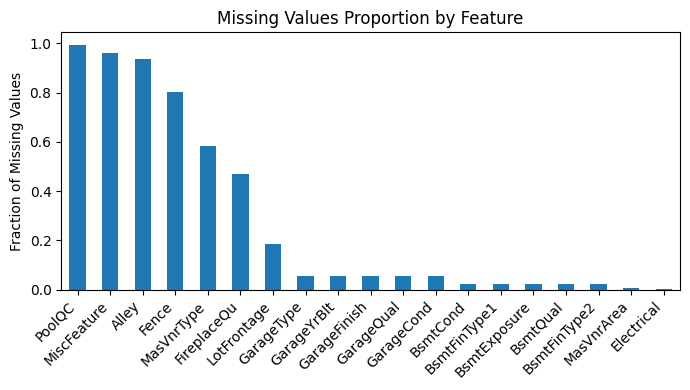

In [16]:
import matplotlib.pyplot as graph

missing_frac=X_train.isna().mean()
missing_frac = missing_frac[missing_frac > 0].sort_values(ascending=False)

graph.figure(figsize=(7, 4))
missing_frac.plot(kind='bar')
graph.title('Missing Values Proportion by Feature')
graph.ylabel('Fraction of Missing Values')
graph.xticks(rotation=45, ha='right')
graph.tight_layout()
graph.show()

In [17]:
threshold = 0.8
cols_to_drop = missing_frac[missing_frac > threshold].index

<h1>Cleaning</h1>

In [18]:
X_train=X_train.drop(columns=cols_to_drop)
X_val=X_val.drop(columns=cols_to_drop)

In [19]:
cat_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
num_cols = [col for col in X_train.columns if X_train[col].dtype != 'object']

In [20]:
meanVal=X_train[num_cols].mean()
X_train[num_cols]=X_train[num_cols].fillna(meanVal)
X_val[num_cols]=X_val[num_cols].fillna(meanVal)

modeVal=X_train[cat_cols].mode().iloc[0]
X_train[cat_cols]=X_train[cat_cols].fillna(modeVal)
X_val[cat_cols]=X_val[cat_cols].fillna(modeVal)

In [ ]:
with mlflow.start_run(run_name="Data_Cleaning"):
    mlflow.log_param("missing_threshold", threshold)
    mlflow.log_param("num_imputation", "mean")
    mlflow.log_param("cat_imputaion", "mode")
    mlflow.log_param("dropped_NA_columns", list(cols_to_drop))

    for col in num_cols:
        mlflow.log_param(f"mean_{col}", meanVal[col])

    for col in cat_cols:
        mlflow.log_param(f"mode_{col}", modeVal[col])

    mlflow.log_metric("train_rows", X_train.shape[0])
    mlflow.log_metric("train_cols", X_train.shape[1])
    mlflow.log_metric("val_rows", X_val.shape[0]) 
    mlflow.log_metric("val_cols", X_val.shape[1])
    